Introduction:
Here is the link to my dataset: https://www.kaggle.com/datasets/quanthan/top-15000-ranked-anime-dataset-update-to-32025


The dataset "top_anime_dataset_v2" is a dataset containing the top 15,000 anime ranked by MAL score. The score is created by averaging MyAnimeList users rating of the anime on a scale from 1-10.

Here is a breakdown of all of the variables and what they represent.
* anime_id: Unique identifier for the anime on MyAnimeList (MAL ID).
* anime_url: URL link to the anime's page on MyAnimeList.
* image_url: URL of the anime's main visual or cover image (JPEG format).
* name: Official title of the anime.
* english_name: Official English title of the anime, if available.
* japanese_names: Official Japanese title of the anime, if available.
* score: Average score/rating of the anime on MyAnimeList (ranging from 1 to 10, higher is better).
* genres: Comma-separated list of genres associated with the anime (e.g., Action, Comedy, Fantasy).
* themes: Comma-separated list of themes associated with the anime (eg: Psychological, Time Travel)
* demographics: Target audiences of the anime (shounen, shoujo, seinen, josei)
* synopsis: A brief summary or plot description of the anime.
* type: Type of anime (e.g., TV, Movie, OVA, ONA, Special, Music).
* episodes: Number of episodes in the anime series (for TV series, OVAs, etc.).
* premiered: Season and year the anime premiered (e.g., "Fall 2013").
* producers: Comma-separated list of production companies involved in creating the anime.
* studios: Comma-separated list of animation studios responsible for the anime's animation.
* source: Original source material for the anime (e.g., Manga, Original, Light novel, Game).
* duration: Duration of each episode in minutes (for TV series, OVAs, etc.).
* rating: Age rating or content rating for the anime (e.g., PG-13, R+, G).
* rank: Ranking of the anime based on its score (lower rank is better). This dataset focuses on the top 15,000 anime by this rank.
* popularity: Popularity rank of the anime on MyAnimeList (lower rank is more popular).
* favorites: Number of users who have marked this anime as a favorite on MyAnimeList.
* scored_by: Number of users who have contributed to the anime's score.
* members: Number of users who are listed as members of the anime's MyAnimeList community.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
from sklearn import linear_model, metrics, model_selection

In [3]:
top_anime_dataset_v2 = pd.read_csv("top_anime_dataset_v2.csv")
print(top_anime_dataset_v2)

       anime_id                                          anime_url  \
0         52991  https://myanimelist.net/anime/52991/Sousou_no_...   
1          5114  https://myanimelist.net/anime/5114/Fullmetal_A...   
2          9253     https://myanimelist.net/anime/9253/Steins_Gate   
3         60022  https://myanimelist.net/anime/60022/One_Piece_...   
4         38524  https://myanimelist.net/anime/38524/Shingeki_n...   
...         ...                                                ...   
14995      4840  https://myanimelist.net/anime/4840/MEM__Yogosa...   
14996     35996  https://myanimelist.net/anime/35996/Naeil-eun_...   
14997     36095  https://myanimelist.net/anime/36095/Mirror_Mir...   
14998     37465  https://myanimelist.net/anime/37465/Echo__Koda...   
14999     38073  https://myanimelist.net/anime/38073/Kkoma_Bus_...   

                                               image_url  \
0      https://cdn.myanimelist.net/images/anime/1015/...   
1      https://cdn.myanimelist.net/imag

In [6]:
#top_anime_dataset_v2 = top_anime_dataset_v2.dropna(subset=['rank'])
#print(top_anime_dataset_v2)

The first question I'd like to answer is 
* What are the most common genres among the highest-rated anime?

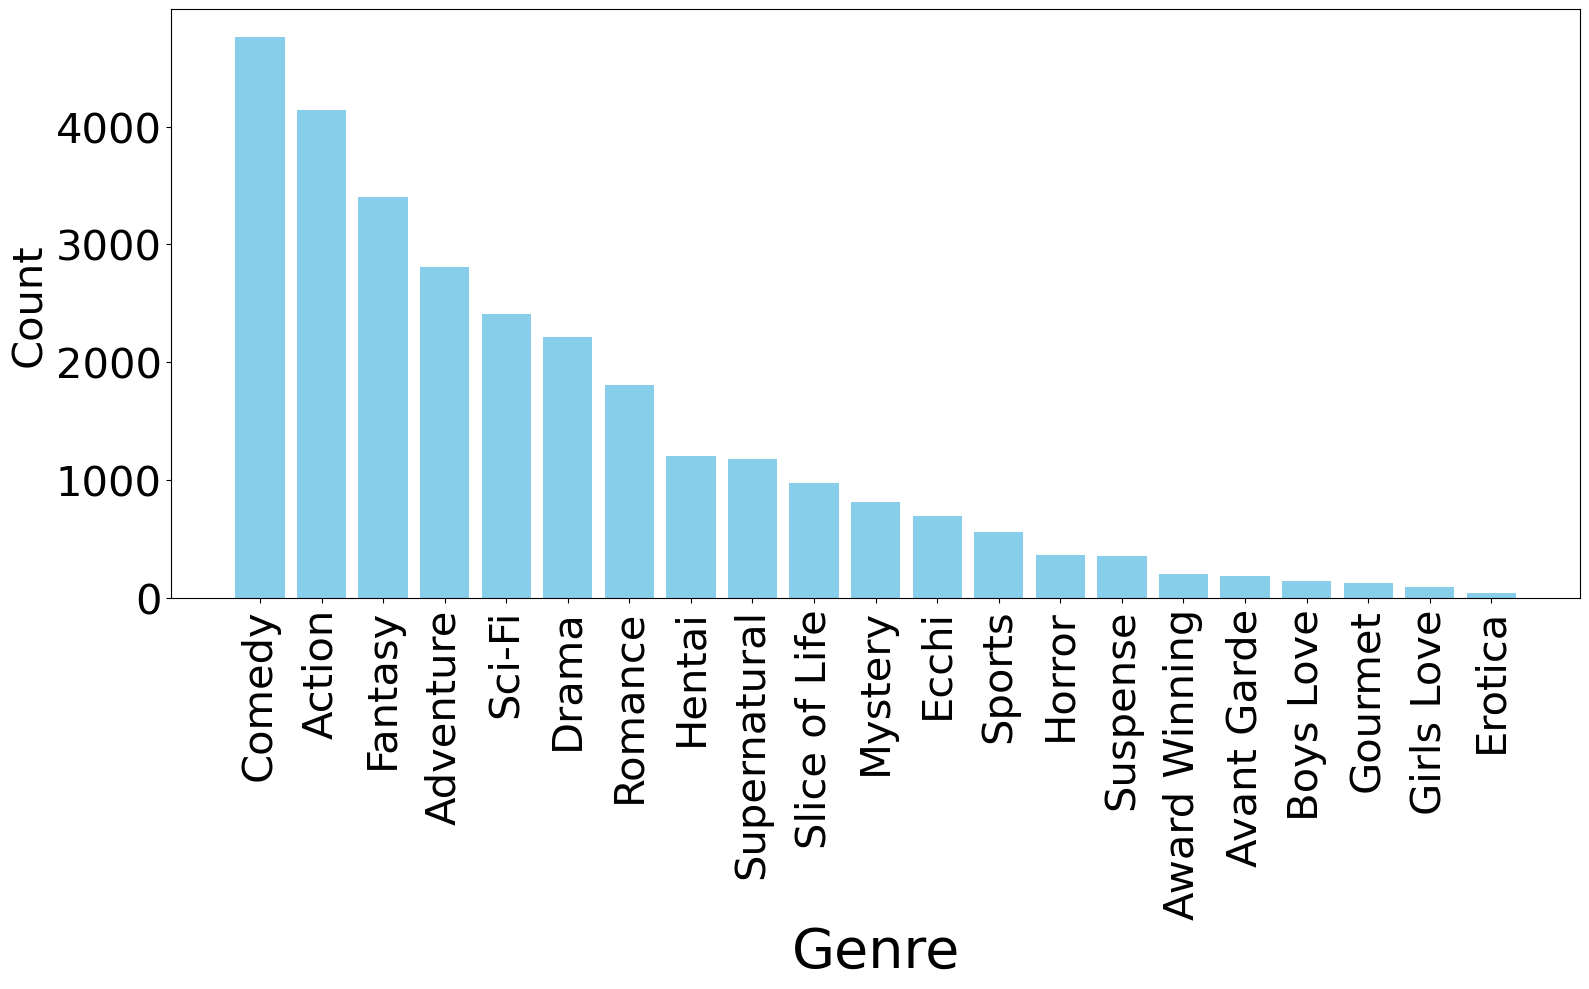

In [9]:

# remove rows with NaN in the 'genres' column
top_anime_filtered = top_anime_dataset_v2.dropna(subset=['genres'])

# split the genres by comma and flatten the list to count individual genres
all_genres = top_anime_filtered['genres'].str.split(',').explode().str.strip()

# count the frequency of each genre
genre_counts = Counter(all_genres)

# create a DataFrame for plotting
genre_df = pd.DataFrame(genre_counts.items(), columns=['Genre', 'Count']).sort_values(by='Count', ascending=False)

# bar Chart of the top genres
plt.figure(figsize=(16, 10))  # Made it a little wider for long genre names
plt.bar(genre_df['Genre'], genre_df['Count'], color='skyblue')
plt.xticks(rotation=90, fontsize=30)  # Bigger x-axis labels
plt.yticks(fontsize=30)                # Bigger y-axis labels
plt.xlabel('Genre', fontsize=40)        # Bigger x-axis title
plt.ylabel('Count', fontsize=30)        # Bigger y-axis title
plt.tight_layout()  # Adjusts layout to prevent label cutoff
plt.show()

# its so smoooooooth of a curve

It seems like the most popular genres of highly rated anime is Comedy, Action, and Fantasy in that order. Comedy having 5000 instances of the top 15000 anime is surprising. However, since anime are allowed to have more than one genre, this makes more sense, as comedy is a very general topic allowing many anime to be in the comedy genre. It might be more insightful to explore what percentage of the total genre tags are made up by these commonly used genres using a pie chart.

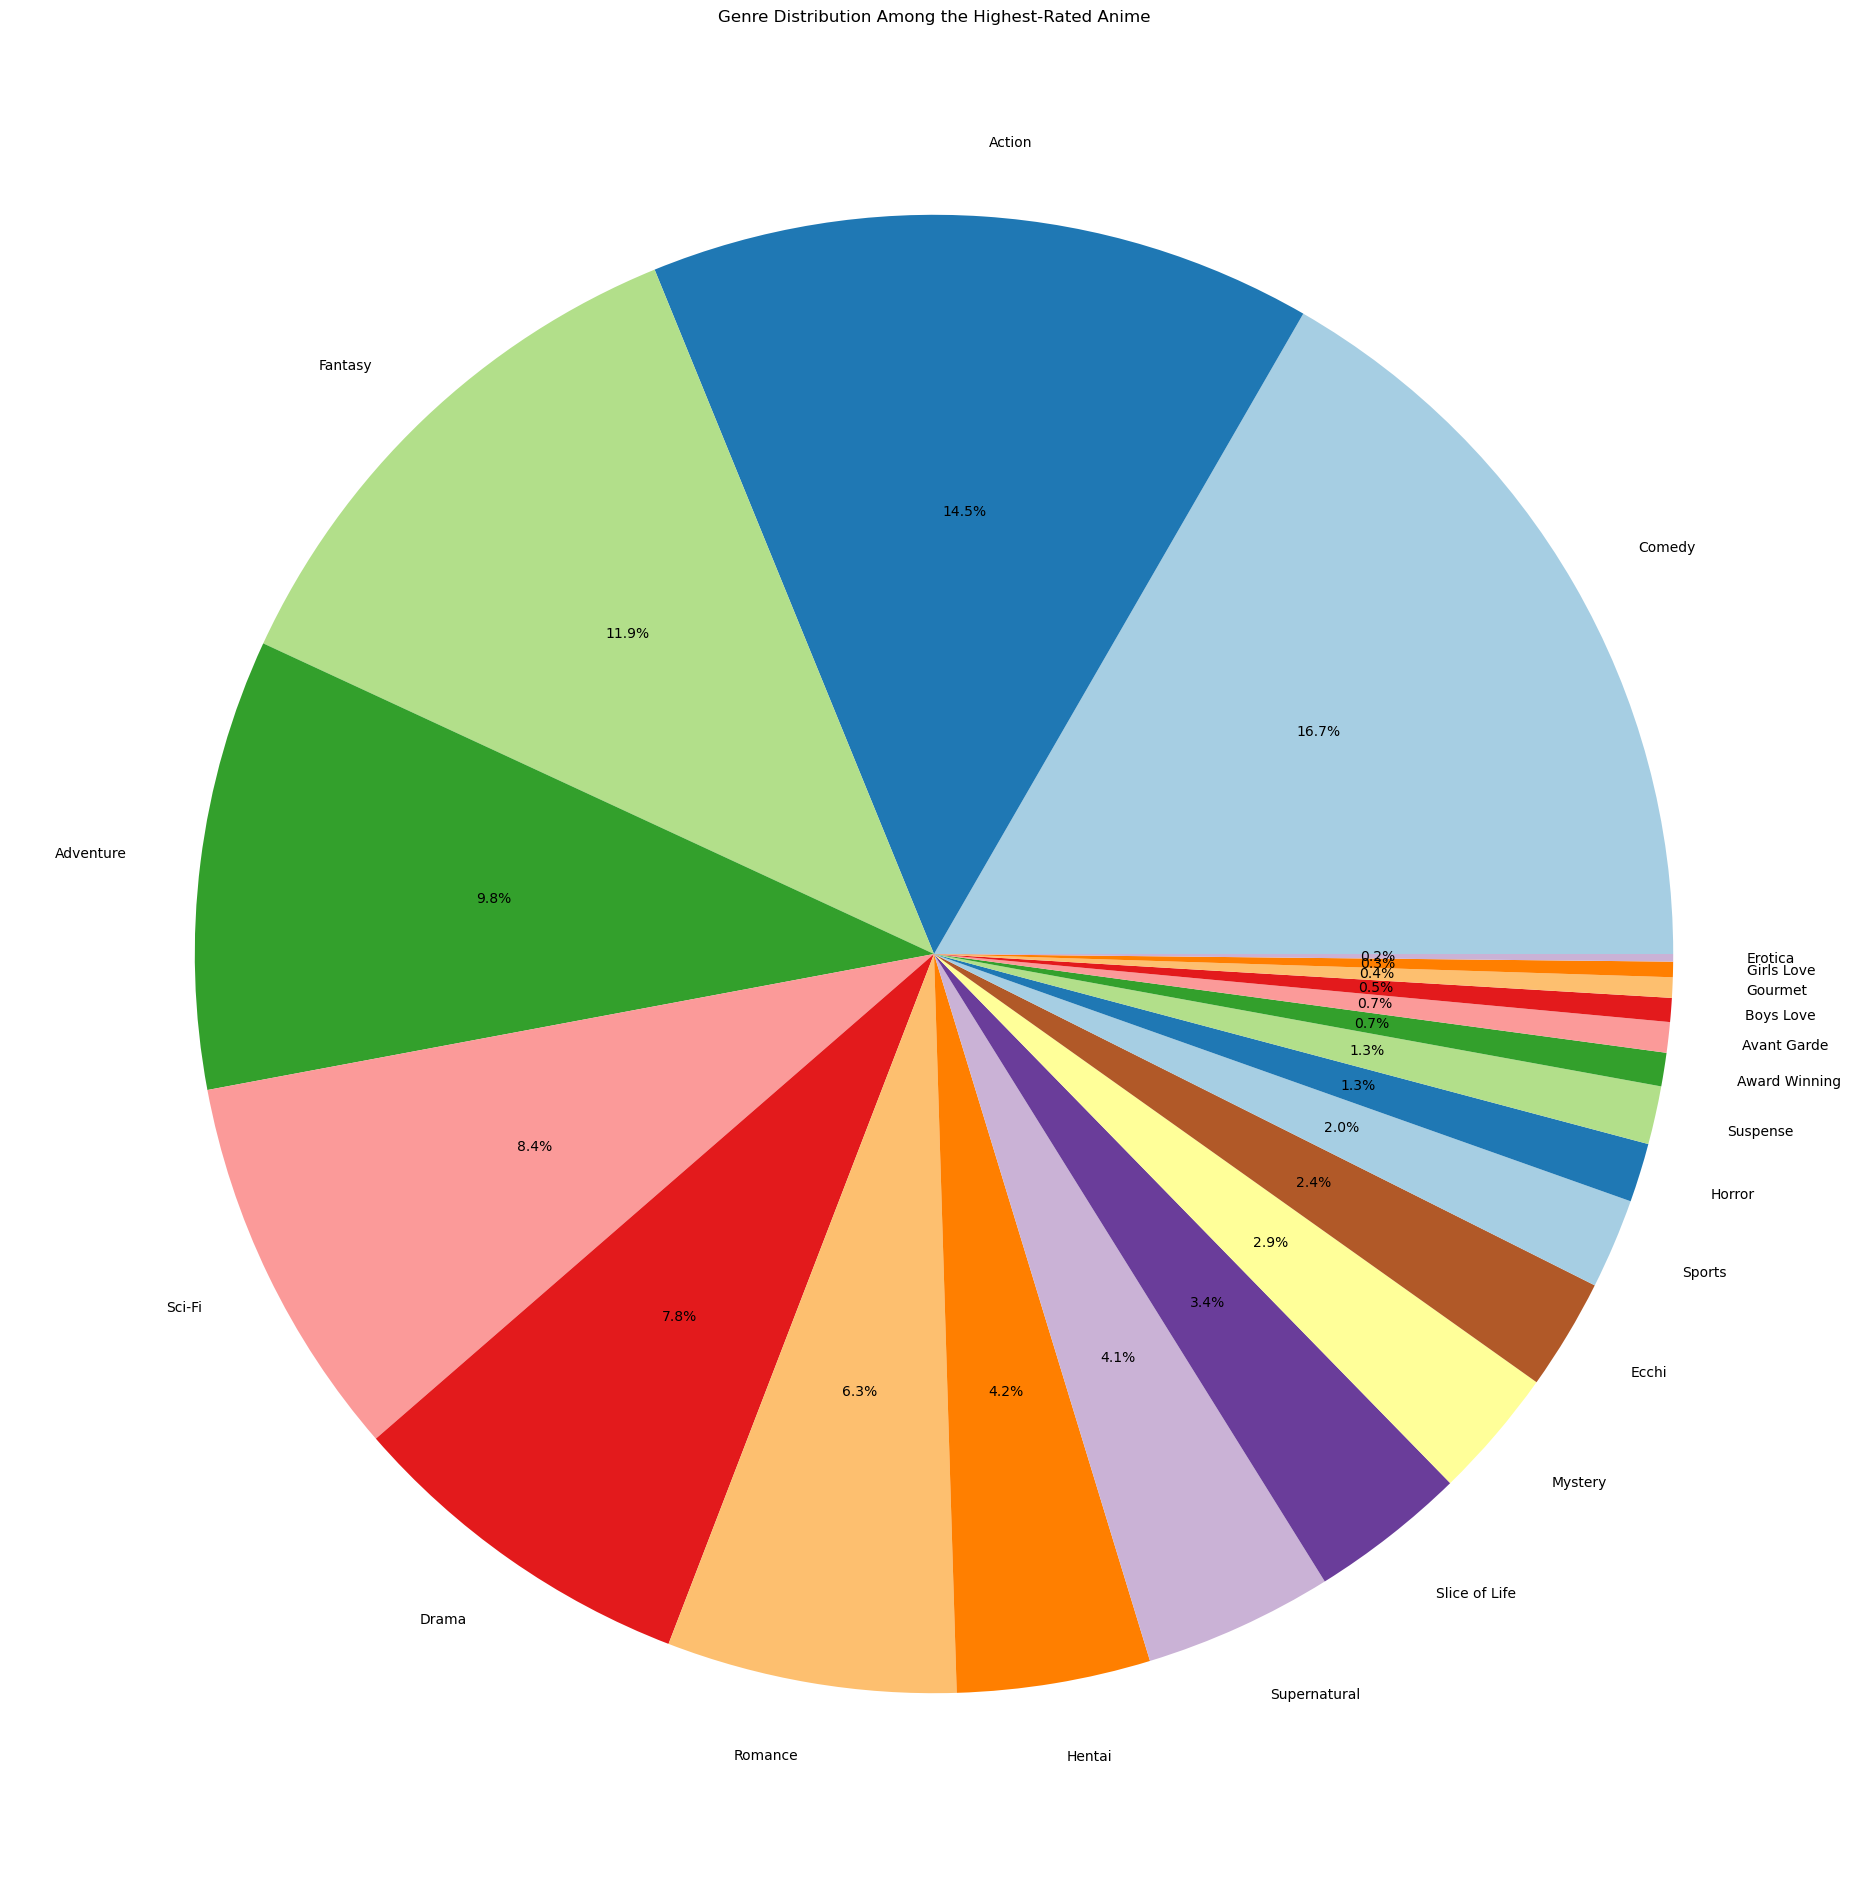

In [12]:
# pie chart of the top genres
plt.figure(figsize=(24, 24))
plt.pie(genre_df['Count'], labels=genre_df['Genre'], autopct='%1.1f%%', colors=plt.cm.Paired.colors)
plt.title('Genre Distribution Among the Highest-Rated Anime')
plt.show()

I can easily tell now that over half of all genres of anime include Comedy, Action, Fantasy, and Adventure. This goes to show just how common these 4 genre actually are, and how well anime of these genres tend to do.

The second question I'd like to ask is
* Is there a Correlation between anime popularity and anime rating?

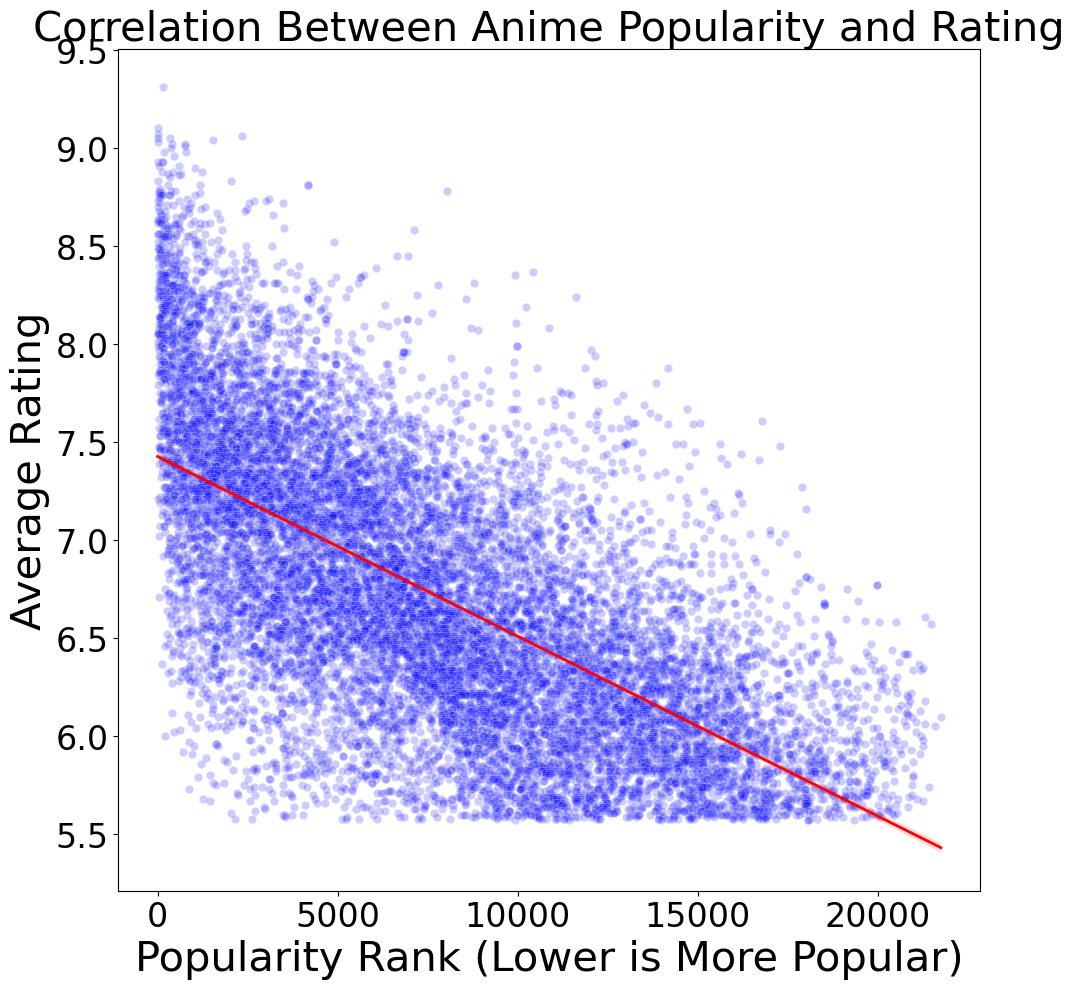

In [16]:
# remove anime with no rating
#print(top_anime_dataset_v2)
#top_anime_filtered = top_anime_dataset_v2.dropna(subset=['popularity', 'score'])
#print(top_anime_filtered)
# apparently this dataset doesn't have a single instance of a missing rating, which makes sense for a dataset with the top rated anime, and this code is not used

# create scatter plot
plt.figure(figsize=(10, 10))
sns.scatterplot(x='popularity', y='score', data=top_anime_filtered, color='blue', alpha=0.2)
sns.regplot(x='popularity', y='score', data=top_anime_filtered, scatter=False, color='red', line_kws={'linewidth': 2})
# title and labels with larger font size
plt.title('Correlation Between Anime Popularity and Rating', fontsize=30)
plt.xlabel('Popularity Rank (Lower is More Popular)', fontsize=30)
plt.ylabel('Average Rating', fontsize=30)
# make tick labels bigger too
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.tight_layout()  # Avoid cutting off labels
plt.show()

There is an enormous variance between popular anime and average rating
The only meaningful data I can get out of this is: anime that is really low rated can be extremely popular, like sword art online II (https://myanimelist.net/anime/21881/Sword_Art_Online_II) its rank is 5863 and a score of 6.71 but its popularity is #40. This is interesting because theres another anime called Touhikou (https://myanimelist.net/anime/57624/Touhikou) that has a score of 6.71 as well but a popularity of 19910, which is in the bottom 353 least popular anime in the dataset out of 15000. It goes to show how anime popularity and average rating can be extremely uncorrelated with each other at lower scores. 

However, there is a trend that suggests that if an anime is of a certain popularity, there is an upper limit for how popular it can become, like how anime in the 15,000 in popularity won't have an average rating higher than an 8.0.
Another interesting point of notice it that because this is a dataset of the top 15,000 anime by ranking assuming that an anime is as popular as its ranking would mean there really shouldn't be many if any cases of anime having a popularity rank of over 15,000. This however isn't the case, as the these anime go even farther than 20,000 in ranking.

In [18]:
sao_ii = top_anime_dataset_v2[top_anime_dataset_v2['name'] == "Sword Art Online II"]
print(sao_ii)
Touhikou = top_anime_dataset_v2[top_anime_dataset_v2['name'] == "Touhikou"]
print(Touhikou)

      anime_id                                          anime_url  \
6497     21881  https://myanimelist.net/anime/21881/Sword_Art_...   

                                              image_url                 name  \
6497  https://cdn.myanimelist.net/images/anime/1223/...  Sword Art Online II   

             english_name   japanese_names  score  \
6497  Sword Art Online II  ソードアート・オンライン II   6.71   

                                   genres                    themes  \
6497  Action, Adventure, Fantasy, Romance  Love Polygon, Video Game   

     demographics  ...                                          producers  \
6497          NaN  ...  Aniplex, Genco, ASCII Media Works, Bandai Namc...   

           studios       source       duration                     rating  \
6497  A-1 Pictures  Light novel  23 min per ep  PG-13 - Teens 13 or older   

        rank popularity favorites scored_by  members  
6497  5863.0         40      9432   1368962  2039447  

[1 rows x 24 columns]
      a

In [21]:
anime_score_671 = top_anime_dataset_v2[top_anime_dataset_v2['score'] == 6.71]
anime_score_671_sorted = anime_score_671.sort_values(by='popularity', ascending=False)
#print(anime_score_671_sorted)
print(anime_score_671_sorted)

anime_count = top_anime_dataset_v2[top_anime_dataset_v2['popularity'] > 19910].shape[0]
print(f"Number of anime with popularity greater than 19910: {anime_count}")

      anime_id                                          anime_url  \
6480     57624       https://myanimelist.net/anime/57624/Touhikou   
6478     58866  https://myanimelist.net/anime/58866/Mahou_Shou...   
6481     57656  https://myanimelist.net/anime/57656/Yi_Ren_Jun...   
6486     51587    https://myanimelist.net/anime/51587/Mirror_Tune   
6487     50898  https://myanimelist.net/anime/50898/Shen_Wu_Ti...   
...        ...                                                ...   
6544     10897  https://myanimelist.net/anime/10897/Boku_wa_To...   
6548       149         https://myanimelist.net/anime/149/Loveless   
6542     11703   https://myanimelist.net/anime/11703/Code_Breaker   
6517      7088  https://myanimelist.net/anime/7088/Ichiban_Ush...   
6497     21881  https://myanimelist.net/anime/21881/Sword_Art_...   

                                              image_url  \
6480  https://cdn.myanimelist.net/images/anime/1403/...   
6478  https://cdn.myanimelist.net/images/anime/1061/.

The next question I'd like to ask is:
What correlations can be found between the characteristics of anime and its ranking?

In [24]:
top_anime_dataset_v2 = pd.read_csv("top_anime_dataset_v2.csv")
#I need to drop these coloumns as this information is very specific to individual anime only, or too random for the model to attempt to make sense of it.
top_anime_dataset_v2_filtered = top_anime_dataset_v2.drop(columns=['anime_id','anime_url','image_url','name','english_name','japanese_names','synopsis'])
print(top_anime_dataset_v2_filtered.head())
top_anime_dataset_v2_filtered = pd.get_dummies(top_anime_dataset_v2_filtered)
print(top_anime_dataset_v2_filtered.head())
#quantitative_columns = top_anime_dataset_v2.select_dtypes(include=['number']).columns
quantitative_dataset = top_anime_dataset_v2_filtered.dropna()
print(quantitative_dataset.head())

   score                             genres                      themes  \
0   9.31          Adventure, Drama, Fantasy                         NaN   
1   9.10  Action, Adventure, Drama, Fantasy                    Military   
2   9.07            Drama, Sci-Fi, Suspense  Psychological, Time Travel   
3   9.06         Action, Adventure, Fantasy                         NaN   
4   9.05            Action, Drama, Suspense    Gore, Military, Survival   

  demographics        type  episodes    premiered  \
0      Shounen          TV      28.0    fall 2023   
1      Shounen          TV      64.0  spring 2009   
2          NaN          TV      24.0  spring 2011   
3      Shounen  TV Special       1.0          NaN   
4      Shounen          TV      10.0  spring 2019   

                                           producers         studios  \
0  Aniplex, Dentsu, Shogakukan-Shueisha Productio...        Madhouse   
1  Aniplex, Square Enix, Mainichi Broadcasting Sy...           Bones   
2  Frontier Wo

In [26]:


X = quantitative_dataset.drop(columns=['popularity'])
y = quantitative_dataset['popularity']

X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, test_size=.2, random_state=123
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (9494, 8249)
X_test shape: (2374, 8249)
y_train shape: (9494,)
y_test shape: (2374,)


In [28]:
reg = linear_model.Ridge(alpha=10).fit(X_train, y_train)

In [29]:
coef_out = pd.DataFrame({"columns": X_test.columns,"coefficient": reg.coef_}).sort_values("coefficient")
display(coef_out)
coef_out.to_csv("coef_out.csv", index=False)

,columns,coefficient
7560,studios_Studio Ghibli,-2924.506747
38,"genres_Action, Adventure, Comedy, Fantasy, Sci-Fi",-2241.959981
8247,rating_R+ - Mild Nudity,-2100.354960
4493,producers_Netflix,-1882.452647
8246,rating_R - 17+ (violence & profanity),-1875.067731
...,...,...
5940,producers_Tamabi,1845.344942
6812,studios_Fenz,2097.495577
1371,"themes_Historical, Martial Arts",2224.278181
6487,producers_miHoYoAnime,2326.030197


Its interesting to see that the largest coefficient for if an anime was more popular was if it was made by Studio Ghibli. It makes sense as it is an extremely popular studio with many fans of it who watch every animation they create.

In [31]:
y_pred_train = reg.predict(X_train)
#Anime can only be the #1 most popular anime, so preditions below one are set to one for higher R2 scores.
y_pred_train = np.maximum(y_pred_train, 1)
print(metrics.r2_score(y_train, y_pred_train))
rmse = metrics.mean_squared_error(y_train, y_pred_train, squared=False)
print("RMSE:", rmse)

0.8311308502226695
RMSE: 2086.2273573500624


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


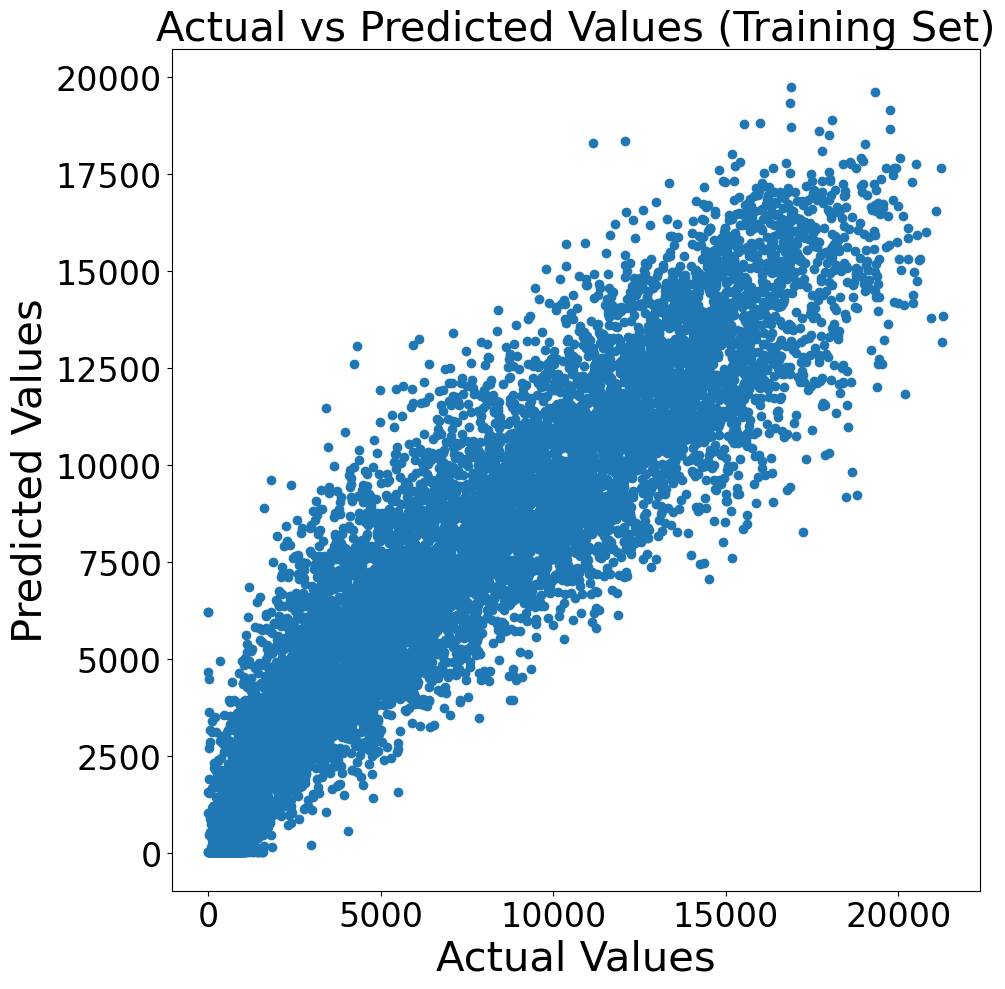

In [33]:
plt.figure(figsize=(10, 10))
plt.plot(y_train, y_pred_train, linestyle="", marker="o")

plt.title('Actual vs Predicted Values (Training Set)', fontsize=30)
plt.xlabel('Actual Values', fontsize=30)
plt.ylabel('Predicted Values', fontsize=30)

# Increase the tick label size
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)

plt.tight_layout()  # Prevent label cutoff
plt.show()

The training set looks fairly accurate in its current form, despite only giving the model basic information about these anime. at the very least I know the model works somewhat well since it isn't confusing animes that aren't popular with anime's that are popular fairly well as most of the data falls along the diagonal line, indicating that the values predicted are close to the actual values. 

In [36]:
y_pred = reg.predict(X_test)
#Anime can only be the #1 most popular anime, so preditions below one are set to one for higher R2 scores.
y_pred = np.maximum(y_pred, 1)
print(metrics.r2_score(y_test, y_pred))
rmse = metrics.mean_squared_error(y_test, y_pred, squared=False)
print("RMSE:", rmse)


0.7766411552870222
RMSE: 2382.663422324667


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


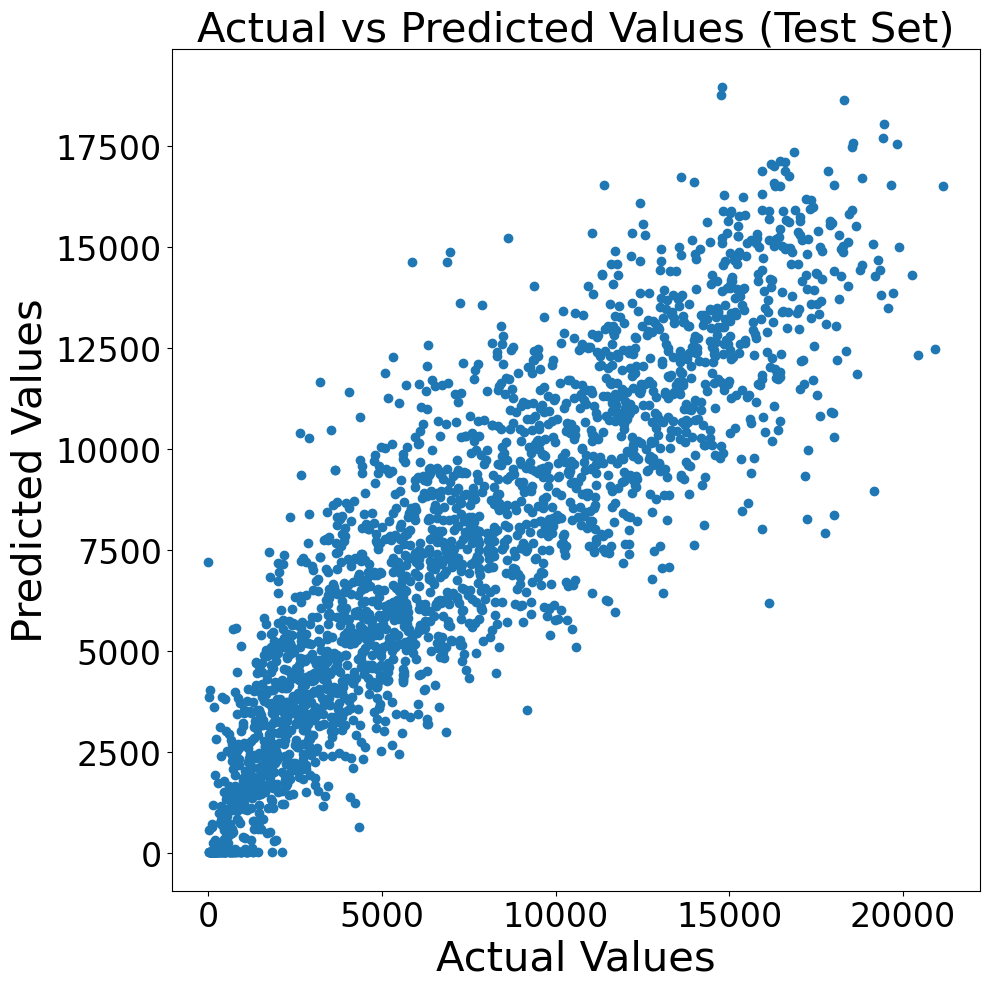

In [37]:
plt.figure(figsize=(10, 10))
plt.plot(y_test, y_pred, linestyle="", marker="o")

# Add title and labels with larger font size
plt.title('Actual vs Predicted Values (Test Set)', fontsize=30)
plt.xlabel('Actual Values', fontsize=30)
plt.ylabel('Predicted Values', fontsize=30)

# Increase the tick label size
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)

plt.tight_layout()  # Prevent label cutoff
plt.show()

This graph looks significantly more spread out compared to the training data, likely due to some form of over fitting in the model but increasing alpha, while it does bring test accuracy closer to training accuracy, significantly impairs the accuracy of both training and tesing accuaracy overall. With that being said I can deduce from r2 score in the last section, 77.66% of the variance in anime popularity (the independent variable) can be explained by my model using the available anime information (dependent variables)

Explain the independent and dependent variables used to train the model.

Independent Variables:

Quantitative:
* score: Average score/rating of the anime on MyAnimeList (ranging from 1 to 10, higher is better).
* favorites: Number of users who have marked this anime as a favorite on MyAnimeList.
* scored_by: Number of users who have contributed to the anime's score.
* members: Number of users who are listed as members of the anime's MyAnimeList community.
* episodes: Number of episodes in the anime series (for TV series, OVAs, etc.).
* rank: Ranking of the anime based on its score (lower rank is better). This dataset focuses on the top 15,000 anime by this rank.
1 Hot Encoded Categorical:
* rating: Age rating or content rating for the anime (e.g., PG-13, R+, G).
* duration: Duration of each episode in minutes (for TV series, OVAs, etc.).
* source: Original source material for the anime (e.g., Manga, Original, Light novel, Game).
* studios: Comma-separated list of animation studios responsible for the anime's animation.
* producers: Comma-separated list of production companies involved in creating the anime.
* premiered: Season and year the anime premiered (e.g., "Fall 2013").
* type: Type of anime (e.g., TV, Movie, OVA, ONA, Special, Music).
* demographics: Target audiences of the anime (shounen, shoujo, seinen, josei)
* themes: Comma-separated list of themes associated with the anime (eg: Psychological, Time Travel)
* genres: Comma-separated list of genres associated with the anime (e.g., Action, Comedy, Fantasy).

Dependent Variable:
* popularity: Popularity rank of the anime on MyAnimeList (lower rank is more popular).

  
Evaluate the model on your test set using appropriate metrics (e.g. RMSD, R2 score).
R^2 Score: 0.7766411552870222
RMSE: 2382.663422324667

Interpret the results (would you recommend this model be used for prediction in the
future? Does it seem to be overfitting or underfitting?)
I would say the current model does an alright job at predicting popularity, however the more unpopular an anime is (higher number) the less accurate the model becomes.
The model seems to be underfitting, since there are a lot of coefficients at or near 0, but this could very well be information that is not useful for predicting popularity. More data would help with accuracy to make the model fit much better.

In [43]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Drop all columns that start with "type" (including 'type_TV')
X = quantitative_dataset.drop(columns=[col for col in quantitative_dataset.columns if col.startswith('type')])

# Target variable
y = quantitative_dataset['type_TV']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Initialize and train logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[1414   76]
 [  86  798]]

Classification Report:
              precision    recall  f1-score   support

       False       0.94      0.95      0.95      1490
        True       0.91      0.90      0.91       884

    accuracy                           0.93      2374
   macro avg       0.93      0.93      0.93      2374
weighted avg       0.93      0.93      0.93      2374



/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


True positive and true negatives are the large majority of prediction on whether the model can accurately predict if the type of anime was TV or not.
* 95% of the Anime that was not for TV was correctly predicted to be false
* 90% of the Anime that was for TV was correctly predicted to be true.
* 93% of the time the model successfully predicted whether the anime was for TV or not.

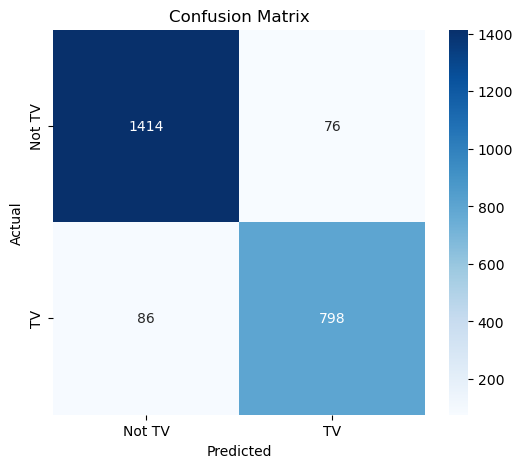

In [47]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not TV', 'TV'], yticklabels=['Not TV', 'TV'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Explain the independent and dependent variables used to train the model.

Independent Variables:

Quantitative:
* score: Average score/rating of the anime on MyAnimeList (ranging from 1 to 10, higher is better).
* favorites: Number of users who have marked this anime as a favorite on MyAnimeList.
* scored_by: Number of users who have contributed to the anime's score.
* members: Number of users who are listed as members of the anime's MyAnimeList community.
* episodes: Number of episodes in the anime series (for TV series, OVAs, etc.).
* rank: Ranking of the anime based on its score (lower rank is better). This dataset focuses on the top 15,000 anime by this rank.
* popularity: Popularity rank of the anime on MyAnimeList (lower rank is more popular).
1 Hot Encoded Categorical:
* rating: Age rating or content rating for the anime (e.g., PG-13, R+, G).
* duration: Duration of each episode in minutes (for TV series, OVAs, etc.).
* source: Original source material for the anime (e.g., Manga, Original, Light novel, Game).
* studios: Comma-separated list of animation studios responsible for the anime's animation.
* producers: Comma-separated list of production companies involved in creating the anime.
* premiered: Season and year the anime premiered (e.g., "Fall 2013").
* demographics: Target audiences of the anime (shounen, shoujo, seinen, josei)
* themes: Comma-separated list of themes associated with the anime (eg: Psychological, Time Travel)
* genres: Comma-separated list of genres associated with the anime (e.g., Action, Comedy, Fantasy).

Dependent Variable:
* type: Type of anime (e.g., TV, Movie, OVA, ONA, Special, Music).
* specifically if it is TV or not

Evaluate the model using appropriate metrics (e.g. accuracy, confusion matrix).
* Confusion Matrix:
* [[1414   76]
 * [  86  798]]
I can tell there are a significantly more amount of anime not for TV than for TV, as the model is very accurate, but there is a larger count of true negatives than true positives.

Interpret the results (would you recommend this model be used for prediction in the
future?).
I would recommend this model as it is very accurate.

The ethical considerations I have for the dataset are as follows:
Beneficence - The dataset contains sensitive content categories such as violence as well as explicit themes and genres. If the dataset was used for anime recommendations and wasn't made with content rating in mind, it could recommend anime that targets inappropriate material to minors.

Justice - The dataset may overrepresent popular or mainstream anime, typically produced in Japan, and underrepresent works from independent creators, diverse cultures, or marginalized groups. Independent creators may have really amazing animations but if it isn't on MyAnimeList and have enough ratings, it will go unnoticed.

Respect for Law and Public Interest - The dataset sources data from the third-party platform MyAnimeList and was extracted with Jikan API which is a popular albeit unofficial API. If scraped or reused without proper permission or attribution, there could be copyright or terms of service violations.

My conclusions are that:
1. The most common genres of high ranked anime is Comedy, Action, Fantasy, and Adventure.
2. There is a correlation between high ranked anime and popular ranked but it is a weak correlation.
3. 77.66% of the variance in anime popularity (the independent variable) can be explained by my model using the available anime information (dependent variables)
4. 93% of the time the model successfully predicted whether the anime was for TV or not.